In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [6]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.1)

In [7]:
X

array([[ 8.49962210e-01, -5.72059658e-01],
       [ 1.62896109e+00, -2.67666641e-01],
       [ 8.75833295e-01, -3.07713012e-01],
       [ 2.02877974e+00,  2.38682473e-01],
       [ 9.90684222e-01,  1.48872972e-03],
       [ 7.91045919e-01, -2.51224567e-01],
       [ 1.99533828e+00,  1.37685286e-01],
       [ 1.42560673e-01,  2.88728926e-01],
       [-3.12522605e-01,  8.92990693e-01],
       [-4.22801311e-02,  3.56448804e-01],
       [ 5.86779270e-01, -3.56471088e-01],
       [-7.89693555e-01,  7.37527344e-01],
       [ 1.17847077e-01, -2.50656765e-01],
       [-4.10278086e-01,  9.96612046e-01],
       [ 1.36562537e+00, -3.10805392e-01],
       [ 6.69405187e-01,  7.26715211e-01],
       [ 1.35237501e+00, -4.04383248e-01],
       [-8.56098792e-01,  7.84558025e-01],
       [ 5.62831006e-01, -3.32778371e-01],
       [-1.64712855e-02, -5.92876520e-02],
       [ 1.96652446e-01,  5.42652184e-02],
       [ 1.72616038e+00, -1.35299478e-01],
       [ 1.91900327e+00,  1.93922333e-01],
       [ 4.

In [8]:
X_outliers = np.random.uniform(low=-3, high=3, size=(20, 2))
X = np.vstack((X, X_outliers))
X

array([[ 8.49962210e-01, -5.72059658e-01],
       [ 1.62896109e+00, -2.67666641e-01],
       [ 8.75833295e-01, -3.07713012e-01],
       [ 2.02877974e+00,  2.38682473e-01],
       [ 9.90684222e-01,  1.48872972e-03],
       [ 7.91045919e-01, -2.51224567e-01],
       [ 1.99533828e+00,  1.37685286e-01],
       [ 1.42560673e-01,  2.88728926e-01],
       [-3.12522605e-01,  8.92990693e-01],
       [-4.22801311e-02,  3.56448804e-01],
       [ 5.86779270e-01, -3.56471088e-01],
       [-7.89693555e-01,  7.37527344e-01],
       [ 1.17847077e-01, -2.50656765e-01],
       [-4.10278086e-01,  9.96612046e-01],
       [ 1.36562537e+00, -3.10805392e-01],
       [ 6.69405187e-01,  7.26715211e-01],
       [ 1.35237501e+00, -4.04383248e-01],
       [-8.56098792e-01,  7.84558025e-01],
       [ 5.62831006e-01, -3.32778371e-01],
       [-1.64712855e-02, -5.92876520e-02],
       [ 1.96652446e-01,  5.42652184e-02],
       [ 1.72616038e+00, -1.35299478e-01],
       [ 1.91900327e+00,  1.93922333e-01],
       [ 4.

In [9]:
out = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
out

,n_neighbors,20
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,contamination,0.1
,novelty,False
,n_jobs,None


In [10]:
y_pred = out.fit_predict(X)

In [11]:
y_pred

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1

In [12]:
X_inliers = X[y_pred==1]
X_outliers = X[y_pred == -1]
X_inliers

array([[ 8.49962210e-01, -5.72059658e-01],
       [ 1.62896109e+00, -2.67666641e-01],
       [ 8.75833295e-01, -3.07713012e-01],
       [ 2.02877974e+00,  2.38682473e-01],
       [ 9.90684222e-01,  1.48872972e-03],
       [ 7.91045919e-01, -2.51224567e-01],
       [ 1.99533828e+00,  1.37685286e-01],
       [ 1.42560673e-01,  2.88728926e-01],
       [-3.12522605e-01,  8.92990693e-01],
       [-4.22801311e-02,  3.56448804e-01],
       [ 5.86779270e-01, -3.56471088e-01],
       [-7.89693555e-01,  7.37527344e-01],
       [ 1.17847077e-01, -2.50656765e-01],
       [-4.10278086e-01,  9.96612046e-01],
       [ 1.36562537e+00, -3.10805392e-01],
       [ 6.69405187e-01,  7.26715211e-01],
       [ 1.35237501e+00, -4.04383248e-01],
       [-8.56098792e-01,  7.84558025e-01],
       [ 5.62831006e-01, -3.32778371e-01],
       [-1.64712855e-02, -5.92876520e-02],
       [ 1.96652446e-01,  5.42652184e-02],
       [ 1.72616038e+00, -1.35299478e-01],
       [ 1.91900327e+00,  1.93922333e-01],
       [ 4.

In [13]:
X_outliers

array([[ 2.08063872e+00,  4.33083532e-01],
       [ 1.01765435e+00, -2.04015870e-02],
       [ 1.67028617e+00, -5.68280435e-01],
       [ 1.64236454e-01,  4.70922968e-01],
       [ 8.01969285e-02,  5.25858015e-01],
       [-8.14179953e-01, -2.92243881e-02],
       [-2.07793767e-01,  4.33063522e-01],
       [-2.15515778e-01,  4.95564696e-01],
       [ 1.63273366e-01,  1.22980260e+00],
       [ 6.83156015e-02,  5.91679528e-01],
       [-1.23945088e-01,  1.21884255e+00],
       [-9.29868169e-01, -1.37016911e-02],
       [-9.97898451e-01, -2.29006741e-02],
       [ 1.95679486e+00,  5.50566181e-01],
       [ 1.35945817e+00,  9.89600982e-01],
       [-2.79995357e-03, -7.76526637e-01],
       [-7.82592781e-01,  1.88747176e+00],
       [-1.21805271e+00, -2.32966715e+00],
       [ 1.33383098e+00,  1.37878114e-01],
       [-1.22636224e+00,  8.89737507e-01],
       [-2.86327666e+00,  1.33121722e-01],
       [-1.05046668e-01,  2.88202930e+00],
       [ 1.39635386e+00, -2.89377036e+00],
       [ 1.

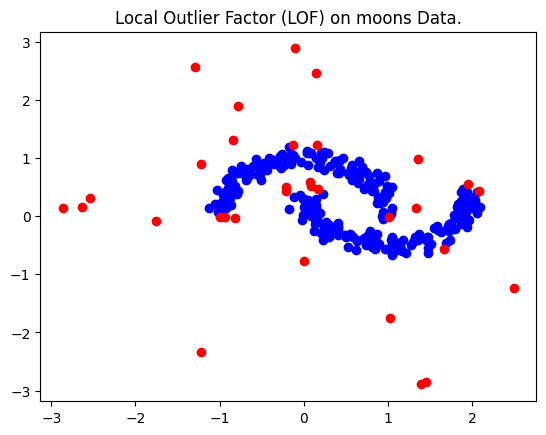

In [16]:
plt.title("Local Outlier Factor (LOF) on moons Data.")
plt.scatter(X_inliers[:, 0], X_inliers[:, 1], color='b')
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], color='r')
